Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 189.0499 - mae: 9.8939 - val_loss: 110.8467 - val_mae: 7.5299
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 77.1425 - mae: 6.5352 - val_loss: 57.9002 - val_mae: 5.2450
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 74.4224 - mae: 6.2607 - val_loss: 56.0782 - val_mae: 6.3287
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 60.8180 - mae: 5.5415 - val_loss: 49.9676 - val_mae: 4.9944
Epoch 5/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 60.9660 - mae: 5.6736 - val_loss: 45.2449 - val_mae: 4.5772
Epoch 6/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 56.7175 - mae: 5.2839 - val_loss: 66.3877 - val_mae: 7.1120
Epoch 7/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 61.5391 - mae: 6.0913 - val_loss: 103.7030 - val_mae: 8.1233
Epoch 8/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 60.4770 - mae: 5.5934 - val_loss: 43.3637 - val_mae: 5.4117
Epoch 9/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 52.048

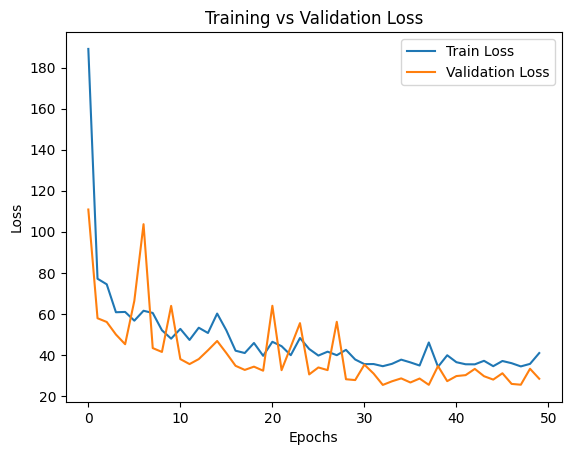

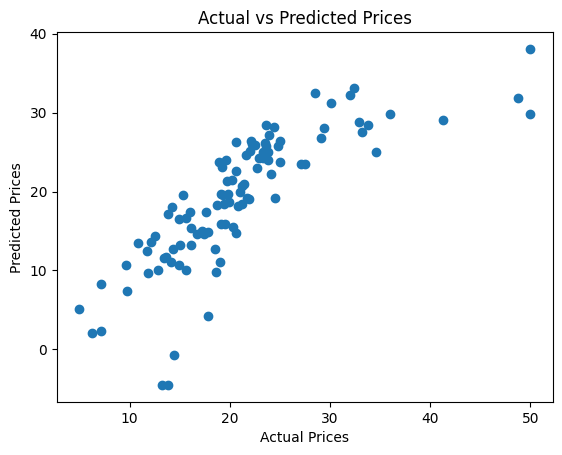

In [1]:
# Step 1: Imports
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Step 2: Load dataset
data = fetch_openml(name="boston", version=1)
X = data.data
y = data.target.astype(float)

# Step 3: Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Step 4: Model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])

# Step 5: Compile
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Step 6: Train (IMPORTANT: validation_data added)
history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=8,
                    validation_split=0.2)

# Step 7: Evaluate
loss, mae = model.evaluate(X_test, y_test)
print("Test Loss (MSE):", loss)
print("Test MAE:", mae)

# Step 8: Predictions
y_pred = model.predict(X_test)

# -------------------------------
# 📊 PLOT 1: Training vs Validation Loss
# -------------------------------
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

# -------------------------------
# 📊 PLOT 2: Actual vs Predicted
# -------------------------------
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()

1. What is the aim of this practical?
    
    To predict house prices using a Deep Neural Network (DNN) implementing Linear Regression.
2. What is Linear Regression?
    
    A technique used to predict continuous values based on input features.
3. Why use a Neural Network for Linear Regression?
    
    Neural networks can:
    Capture complex patterns
    Improve accuracy compared to simple linear models
4. What type of problem is Boston Housing?
    
    Supervised Learning → Regression Problem
5. What is the output of your model?
    
    A single continuous value (house price)

🧠 MODEL RELATED QUESTIONS
6. Why is the output layer Dense(1)?
    
    Because we are predicting one value (price)
7. Why no activation in output layer?
    
    To keep output linear (required for regression)
8. Why use ReLU in hidden layers?
    
    Prevents vanishing gradient problem
    Helps learn non-linear patterns
9. What is Sequential model?
    A linear stack of layers where data flows one-by-one
10. What does Dense layer mean?
    Fully connected layer (each neuron connects to all inputs)

⚙️ TRAINING & PARAMETERS
11. What is epoch?

    One complete pass through training data
12. What is batch size?

    Number of samples processed at once
13. What is optimizer (Adam)?
    
    Algorithm to update weights efficiently
14. What is loss function (MSE)?
    
    Measures difference between actual and predicted values
15. Why use MSE?
    
    Penalizes larger errors more heavily
16. What is MAE?
    
    Mean Absolute Error → average absolute difference

📊 PLOTS RELATED QUESTIONS
17. What does training vs validation loss show?
    
    Model learning behavior
18. What is overfitting?
    
    Model performs well on training but poorly on validation
19. How to identify overfitting in graph?
    
    Validation loss increases while training loss decreases
20. What does Actual vs Predicted graph show?
    
    Accuracy of predictions
21. Ideal shape of Actual vs Predicted plot?
    
    Points lie along a straight diagonal line

📦 DATASET QUESTIONS
22. What is Boston Housing Dataset?
    
    Dataset containing:
    Crime rate
    Rooms
    Tax rate
    etc.
    Used to predict house prices

23. Why is dataset split?
    
    To test model on unseen data
24. What is training and testing data?
    
    Training → learn
    Testing → evaluate

🔥 IMPORTANT CONCEPTUAL QUESTIONS
25. Why is this still called Linear Regression?

    Because output layer is linear
    Even though hidden layers are non-linear
26. What happens if we add activation in output layer?
    
    It becomes non-linear regression
27. Difference between MSE and MAE?
    
    MSE	MAE
    Squares error	Absolute error
    Penalizes large errors more	Easier to interpret
28. What is validation split?

    Portion of training data used for validation during training
29. Why use validation data?

    To monitor model performance and avoid overfitting
30. What happens if epochs are too high?
    
    Overfitting

⚡ ADVANCED (can impress examiner)
31. What is vanishing gradient problem?

    Gradients become very small → slow learning
32. Why use ReLU instead of sigmoid?
    
    Faster training
    Avoids vanishing gradient
33. What is generalization?
    
    Model performing well on unseen data
34. How to improve model performance?
    
    More data
    Better architecture
    Hyperparameter tuning

1. TRAINING OUTPUT (Epoch logs)

Example:

Epoch 1:
loss: 189 → val_loss: 110
Epoch 50:
loss: ~40 → val_loss: ~28
✅ What it means:
loss → error on training data
val_loss → error on validation data

👉 In your case:

Training loss reduced from 189 → ~40
Validation loss reduced from 110 → ~28

✔ This means:
👉 Your model learned successfully
👉 Error is decreasing → good training

📉 2. MAE (Mean Absolute Error)

Example:

mae: 9.8 → ~4.8 (train)
val_mae: 7.5 → ~3.8 (validation)
✅ Meaning:

👉 MAE ≈ average prediction error

So:

Final Test MAE = 3.74

✔ Interpretation:
👉 On average, your model predicts house price with ±3.74 error

💰 3. TEST RESULTS (MOST IMPORTANT FOR VIVA)
Test Loss (MSE): 30.39
Test MAE: 3.74
✅ What this means:
🔹 MSE = 30.39
Squared error (penalizes large mistakes)
Lower is better
🔹 MAE = 3.74
Real-world interpretable error

👉 If house prices are in:

$1000s (Boston dataset standard)

Then:
👉 Your model is off by approx $3740 on average

🎯 FINAL INTERPRETATION (Say this in viva)

👉 “The model shows decreasing training and validation loss, indicating proper learning. The test MAE is around 3.7, which means predictions are close to actual values with small average error. Hence, the model performs reasonably well.”

⚠️ IMPORTANT OBSERVATION (Impress examiner 🔥)

Look at your logs:

Epoch 6 → val_loss jumps (66)
Epoch 7 → val_loss jumps (103)

👉 This indicates:

❗ Slight overfitting / instability

But later it improves again → so model stabilizes.

📈 4. HOW GOOD IS YOUR MODEL?
Metric	Value	Meaning
MSE	~30	Moderate error
MAE	~3.7	Good accuracy
Trend	Decreasing	Model learned

👉 Overall: ✅ Good model (not perfect, but acceptable)

🧠 QUICK MEMORY LINE (for viva)

👉 “Lower loss = better model”
👉 “MAE tells real-world error”
👉 “Validation loss shows generalization”

⚡ BONUS (if they ask improvement)

You can say:

Normalize data
Add more layers
Use early stopping
Tune epochs